## 0. Introduction

This project analyzes NFL team data from 2003–2023 to determine which regular-season characteristics are most associated with Super Bowl success.

The main research question is:

**Which team-level statistics best predict Super Bowl winners, and can we identify realistic championship contenders using machine learning?**

This is a classification problem, but due to extreme class imbalance (only one winner per season), we also use ranking-based evaluation to assess model performance.

This notebook follows the first phase of the data science workflow:
1. Data loading via kagglehub (ensures reproducibility without manual file placement)
2. Target variable creation  
3. Exploratory analysis  

Decision: EDA is isolated in its own notebook to ensure exploratory decisions are documented before any preprocessing or modeling begins. Using `kagglehub` for data loading ensures any collaborator can reproduce the analysis without manually downloading files.

In [1]:
# ============================================
# Setup, Imports & Path Configuration
# ============================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import kagglehub
from pathlib import Path

# ============================================
# Robust Project Root Detection
# ============================================
current_dir = Path.cwd()
if (current_dir / "src").exists() and (current_dir / "notebooks").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists() and (current_dir.parent / "notebooks").exists():
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

# Add project root to sys.path so 'src' can be imported
sys.path.insert(0, str(PROJECT_ROOT))

# Define absolute paths
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Create directories
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Outputs: {OUTPUTS_DIR}")
print(f"Processed: {PROCESSED_DIR}")

# ============================================
# Import Shared Utilities & Reproducibility
# ============================================
from src.utils import evaluate_top_k, ensure_dir

np.random.seed(42)
random.seed(42)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)

print("Setup complete. Ready for EDA.")

Project root: /home/azan_khan/NFL-Prediction-Model
Outputs: /home/azan_khan/NFL-Prediction-Model/outputs
Processed: /home/azan_khan/NFL-Prediction-Model/data/processed
Setup complete. Ready for EDA.


## 1. Data Overview

### Initial Data Inspection

Before constructing the target variable or performing analysis, the dataset is inspected to confirm:
- structure and dimensions,
- column types,
- and overall data integrity.

Decision: Raw data is downloaded via `kagglehub` directly within the notebook. This ensures full reproducibility without requiring manual file placement. The downloaded data is treated as READ-ONLY; all transformations occur in code and are saved to `data/processed/`.

In [2]:
# ============================================
# Load Raw Dataset via kagglehub
# ============================================

# Download dataset using kagglehub (reproducible across environments)
path = kagglehub.dataset_download("nickcantalupa/nfl-team-data-2003-2023")

print("Path to dataset files:", path)

# Find CSV file in downloaded directory
files = os.listdir(path)
csv_file = [f for f in files if f.endswith(".csv")][0]

# Load into dataframe
df = pd.read_csv(os.path.join(path, csv_file))

print("Dataset loaded successfully.")
print("Shape:", df.shape)

# Assertion: Verify expected dimensions after loading
assert df.shape == (672, 35), f"Unexpected dataset dimensions: expected (672, 35), got {df.shape}"

Path to dataset files: /home/azan_khan/.cache/kagglehub/datasets/nickcantalupa/nfl-team-data-2003-2023/versions/1
Dataset loaded successfully.
Shape: (672, 35)


### Dataset Description

The dataset used in this project is the **NFL Team Data 2003–2023** dataset from Kaggle.

**Source:** Kaggle NFL Team Data 2003–2023  
**URL:** https://www.kaggle.com/datasets/nickcantalupa/nfl-team-data-2003-2023  
**Access Date:** 2026-04-15  
**License:** CC0: Public Domain (can be made public)

The dataset contains **672 rows and 35 columns**, where each row represents a single NFL team in a single season.

The dataset contains team-level regular-season statistics, including variables related to:
- scoring,
- defense,
- total offensive production,
- turnovers,
- efficiency,
- and team record.

Decision: Dataset is suitable for supervised learning because it is structured, mostly numeric, and each row represents an independent team-season observation. No manual cleaning is performed at this stage.

In [3]:
# ============================================
# Preview the Dataset
# ============================================

df.head()

,year,team,wins,losses,win_loss_perc,points,points_opp,points_diff,mov,g,total_yards,plays_offense,yds_per_play_offense,turnovers,fumbles_lost,first_down,pass_cmp,pass_att,pass_yds,pass_td,pass_int,pass_net_yds_per_att,pass_fd,rush_att,rush_yds,rush_td,rush_yds_per_att,rush_fd,penalties,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,ties
0,2003,New England Patriots,14,2,0.875,348,238,110,6.9,16,5039,1042,4.8,24,11,294,320,537,3432,23,13,6.0,177,473,1607,9,3.4,91,111,998,26,27.9,11.3,-136.51,NaN
1,2003,Miami Dolphins,10,6,0.625,311,261,50,3.1,16,4609,968,4.8,34,15,266,257,450,2792,17,19,5.8,145,487,1817,14,3.7,99,103,913,22,28.1,17.2,-177.92,NaN
2,2003,Buffalo Bills,6,10,0.375,243,279,-36,-2.3,16,4348,980,4.4,34,17,268,293,502,2684,11,17,4.9,150,427,1664,13,3.9,96,106,891,22,21.9,17.6,-230.07,NaN
3,2003,New York Jets,6,10,0.375,283,299,-16,-1.0,16,4951,936,5.3,20,6,274,312,496,3316,20,14,6.3,181,409,1635,8,4.0,78,69,550,15,32.4,11.8,-107.89,NaN
4,2003,Baltimore Ravens,10,6,0.625,391,281,110,6.9,16,4929,1009,4.9,38,19,259,217,415,2255,16,19,4.9,121,552,2674,18,4.8,115,126,970,23,31.8,16.6,-220.50,NaN


The first few rows help verify that each observation appears to represent a single NFL team in a single season. This is an important structural check before we examine data types, missing values, or build a target variable.

In [4]:
# ============================================
# Inspect Columns and Data Types
# ============================================

df.info()

# ============================================
# Summary Statistics for Numeric Variables
# ============================================

df.describe()

# ============================================
# Inspect Column Names
# ============================================

list(df.columns)

# ============================================
# Check for Missing Values
# ============================================

df.isnull().sum()

# ============================================
# Check for Duplicate Rows
# ============================================

print("Number of duplicate rows:", df.duplicated().sum())

# ============================================
# Check Whether Each Team-Year Combination Is Unique
# ============================================

team_year_duplicates = df.duplicated(subset=["year", "team"]).sum()
print("Duplicate team-year combinations:", team_year_duplicates)

# Assertion: Ensure team-year combinations are unique
assert team_year_duplicates == 0, "Duplicate team-year combinations detected"

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  672 non-null    int64  
 1   team                  672 non-null    object 
 2   wins                  672 non-null    int64  
 3   losses                672 non-null    int64  
 4   win_loss_perc         672 non-null    float64
 5   points                672 non-null    int64  
 6   points_opp            672 non-null    int64  
 7   points_diff           672 non-null    int64  
 8   mov                   352 non-null    float64
 9   g                     672 non-null    int64  
 10  total_yards           672 non-null    int64  
 11  plays_offense         672 non-null    int64  
 12  yds_per_play_offense  672 non-null    float64
 13  turnovers             672 non-null    int64  
 14  fumbles_lost          672 non-null    int64  
 15  first_down            6

### Initial Observations

After loading and inspecting the dataset, we confirmed the following:

- the dataset loads successfully into pandas,
- each row appears to represent one NFL team in one season,
- the variables are team-level season statistics that are appropriate for a predictive sports modeling project,
- and the dataset structure appears suitable for further exploratory analysis.

Decision: No rows were dropped at this stage. Missing values will be handled in the cleaning notebook using training-set statistics only to avoid data leakage.

## 2. Target Variable Definition

### Why This Problem Is Difficult

Only one team per season wins the Super Bowl, making this dataset extremely imbalanced.

This means:
- most teams are labeled 0
- very few are labeled 1

Decision: Because of extreme class imbalance (~0.3% positive class), accuracy alone will be misleading. We will use ranking-based evaluation (Top-K accuracy) as our primary metric, documented in decisions.md before modeling begins.

In [5]:
# ============================================
# Define Super Bowl Winners by Year
# ============================================

super_bowl_winners = {
    2003: "New England Patriots",
    2004: "New England Patriots",
    2005: "Pittsburgh Steelers",
    2006: "Indianapolis Colts",
    2007: "New York Giants",
    2008: "Pittsburgh Steelers",
    2009: "New Orleans Saints",
    2010: "Green Bay Packers",
    2011: "New York Giants",
    2012: "Baltimore Ravens",
    2013: "Seattle Seahawks",
    2014: "New England Patriots",
    2015: "Denver Broncos",
    2016: "New England Patriots",
    2017: "Philadelphia Eagles",
    2018: "New England Patriots",
    2019: "Kansas City Chiefs",
    2020: "Tampa Bay Buccaneers",
    2021: "Los Angeles Rams",
    2022: "Kansas City Chiefs",
    2023: "Kansas City Chiefs"
}

# ============================================
# Create Target Variable: Super Bowl Winner
# ============================================

def is_super_bowl_winner(row):
    year = row["year"]
    team = row["team"]
    return 1 if super_bowl_winners.get(year) == team else 0

df["super_bowl_winner"] = df.apply(is_super_bowl_winner, axis=1)

print("Target variable created.")
df[["year", "team", "super_bowl_winner"]].head(20)

# ============================================
# Check Class Distribution
# ============================================

df["super_bowl_winner"].value_counts()

# Assertion: Verify target variable has expected imbalance
assert df["super_bowl_winner"].sum() == 21, "Expected 21 Super Bowl winners (2003-2023)"

Target variable created.


### Target Variable Observations

The dataset now includes a binary target variable indicating whether a team won the Super Bowl in a given season.

As expected, the data is highly imbalanced, since only one team per season is labeled as a Super Bowl winner. This imbalance will need to be considered during model training and evaluation to avoid misleading results.

Decision: Class imbalance will be addressed using `class_weight='balanced'` in model training and by prioritizing ranking-based metrics over binary classification accuracy.

## 3. Exploratory Data Analysis (EDA)

Now that the target variable has been defined, we explore how Super Bowl-winning teams differ from non-winning teams.

The goal is to identify which features may be strong predictors of championship success.

Decision: EDA visualizations are generated and saved to `outputs/` directory. All figures are reproducible by re-running this notebook.

### Comparing Winners and Non-Winners

To begin the EDA, we compare the average values of key statistics for Super Bowl winners and non-winners.

This helps identify whether championship teams differ systematically from the rest of the league before moving to visualizations and correlation analysis.

In [6]:
# ============================================
# Compare Winners vs Non-Winners (Mean Stats)
# ============================================

winner_stats = df[df["super_bowl_winner"] == 1].mean(numeric_only=True)
non_winner_stats = df[df["super_bowl_winner"] == 0].mean(numeric_only=True)

comparison = pd.DataFrame({
    "Winners": winner_stats,
    "Non-Winners": non_winner_stats
})

comparison.sort_values(by="Winners", ascending=False).head(15)

,Winners,Non-Winners
total_yards,5861.571429,5451.067588
pass_yds,4014.619048,3604.147465
year,2013.000000,2013.000000
rush_yds,1846.952381,1846.920123
plays_offense,1035.000000,1021.488479
penalties_yds,862.809524,849.072197
pass_att,555.238095,546.612903
rush_att,449.857143,437.423963
points,421.666667,356.600614
pass_cmp,352.142857,338.890937


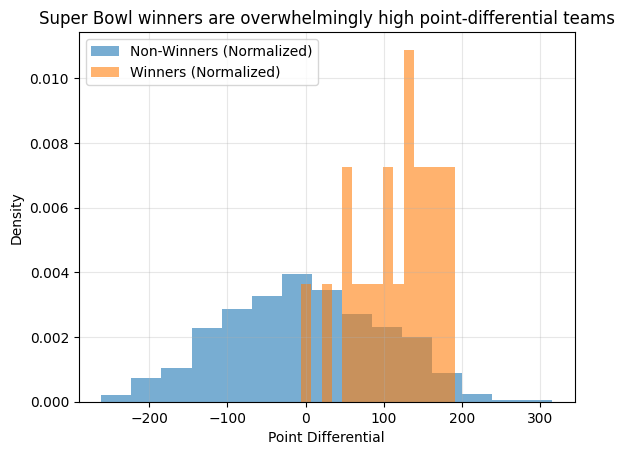

In [7]:
# ============================================
# Visualize Point Differential
# ============================================

plt.figure()

df[df["super_bowl_winner"] == 0]["points_diff"].hist(
    bins=15, density=True, alpha=0.6
)

df[df["super_bowl_winner"] == 1]["points_diff"].hist(
    bins=15, density=True, alpha=0.6
)

plt.title("Super Bowl winners are overwhelmingly high point-differential teams")
plt.xlabel("Point Differential")
plt.ylabel("Density")

plt.legend(["Non-Winners (Normalized)", "Winners (Normalized)"])
plt.grid(True, alpha=0.3)

plt.savefig(OUTPUTS_DIR / "point_diff_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

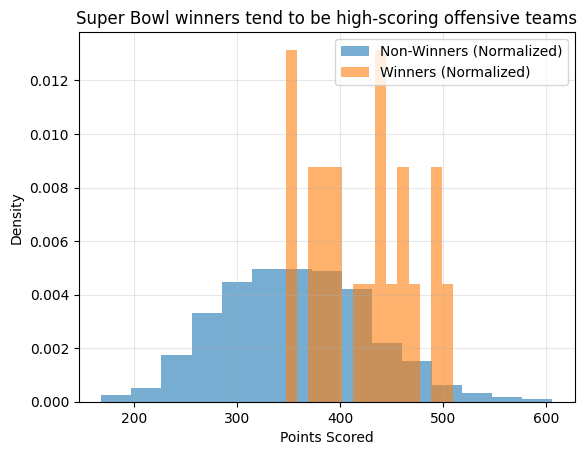

In [8]:
# ============================================
# Visualization: Points Scored
# ============================================

plt.figure()

df[df["super_bowl_winner"] == 0]["points"].hist(
    bins=15, density=True, alpha=0.6
)

df[df["super_bowl_winner"] == 1]["points"].hist(
    bins=15, density=True, alpha=0.6
)

plt.title("Super Bowl winners tend to be high-scoring offensive teams")
plt.xlabel("Points Scored")
plt.ylabel("Density")

plt.legend(["Non-Winners (Normalized)", "Winners (Normalized)"])
plt.grid(True, alpha=0.3)

plt.savefig(OUTPUTS_DIR / "points_scored_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

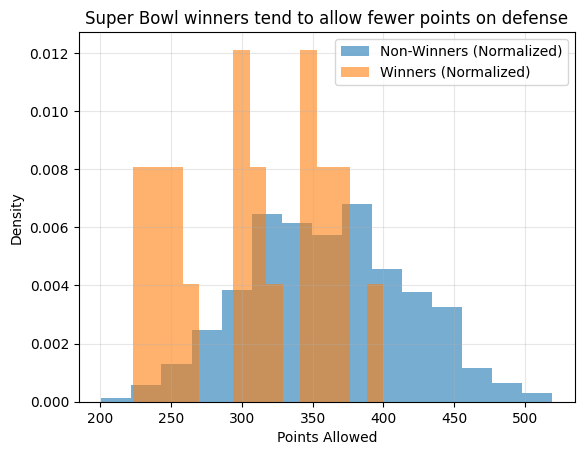

In [9]:
# ============================================
# Visualization: Points Allowed
# ============================================

plt.figure()

df[df["super_bowl_winner"] == 0]["points_opp"].hist(
    bins=15, density=True, alpha=0.6
)

df[df["super_bowl_winner"] == 1]["points_opp"].hist(
    bins=15, density=True, alpha=0.6
)

plt.title("Super Bowl winners tend to allow fewer points on defense")
plt.xlabel("Points Allowed")
plt.ylabel("Density")

plt.legend(["Non-Winners (Normalized)", "Winners (Normalized)"])
plt.grid(True, alpha=0.3)

plt.savefig(OUTPUTS_DIR / "points_allowed_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

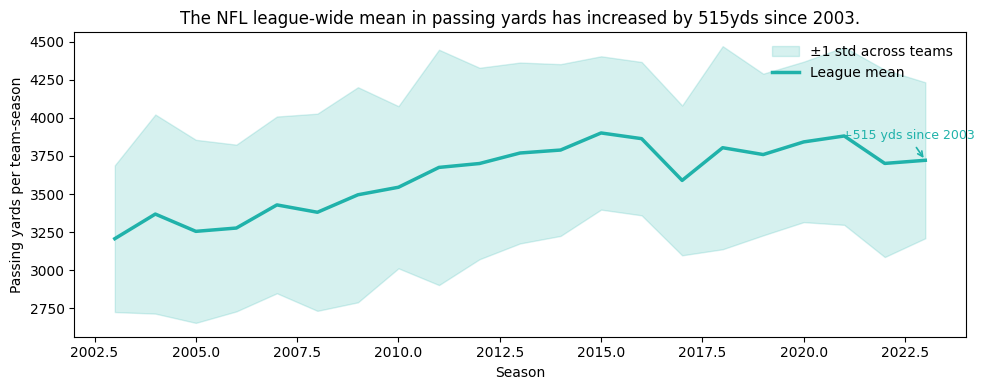

In [10]:
# ============================================
# Visualize League-Wide Passing Yards Mean by Year
# ============================================

league_trend = df.groupby('year')['pass_yds'].agg(['mean','std']).reset_index()
league_trend.columns = ['season','mean_py','std_py']

fig, ax = plt.subplots(figsize=(10, 4))
TEAL = '#20B2AA'
ax.fill_between(league_trend['season'],
                league_trend['mean_py'] - league_trend['std_py'],
                league_trend['mean_py'] + league_trend['std_py'],
                alpha=0.18, color=TEAL, label='±1 std across teams')
ax.plot(league_trend['season'], league_trend['mean_py'],
        color=TEAL, linewidth=2.5, label='League mean')

first_mean = league_trend['mean_py'].iloc[0]
last_mean  = league_trend['mean_py'].iloc[-1]
diff_label = f"+{last_mean-first_mean:.0f} yds since {league_trend['season'].iloc[0]}"
ax.annotate(diff_label,
            xy=(league_trend['season'].iloc[-1], last_mean),
            xytext=(-60, 15), textcoords='offset points',
            fontsize=9, color=TEAL,
            arrowprops=dict(arrowstyle='->', color=TEAL, lw=1.2))

ax.set_xlabel("Season"); ax.set_ylabel("Passing yards per team-season")
ax.legend(frameon=False)

ax.set_title("The NFL league-wide mean in passing yards has increased by 515yds since 2003.")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "passing_yards_trend.png", dpi=300, bbox_inches="tight")
plt.show()

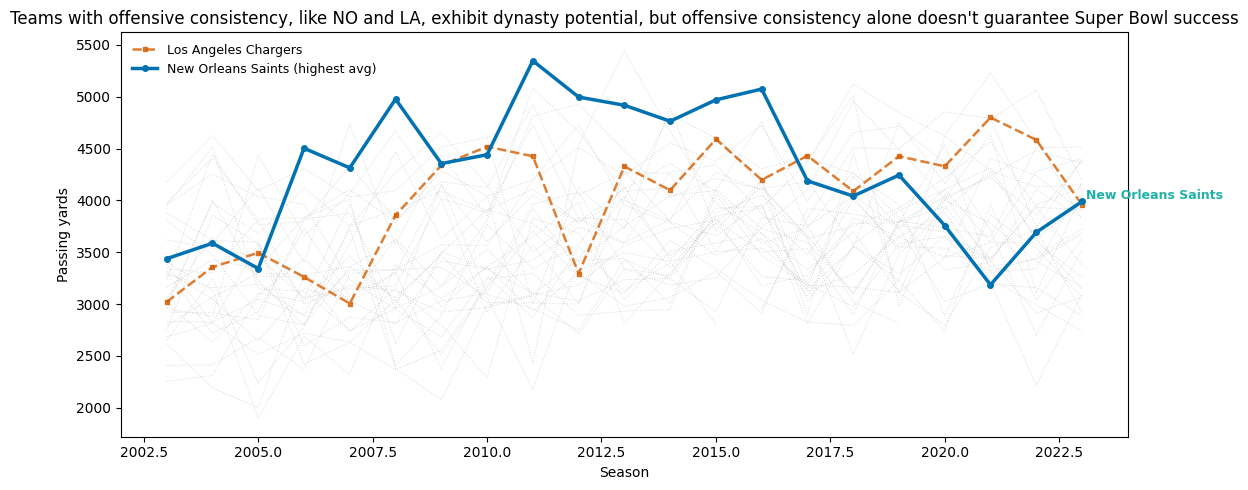

In [11]:
# ============================================
# Visualize Highest Average Passing Yards per Year
# ============================================

fig, ax = plt.subplots(figsize=(12, 5))

# Create a temporary DataFrame for plotting to handle team name changes
df_plot = df.copy()
df_plot['team'] = df_plot['team'].replace('San Diego Chargers', 'Los Angeles Chargers')
df_plot['team'] = df_plot['team'].replace('Oakland Raiders', 'Las Vegas Raiders')

all_teams_plot = df_plot['team'].unique()
CB_BLUE = '#0072B2'
CB_AMBER = '#D55E00'
GREY = '#999999'
TEAL = '#20B2AA'

top_team_plot = df_plot.groupby('team')['pass_yds'].mean().idxmax()
second_team_plot = df_plot.groupby('team')['pass_yds'].mean().nlargest(2).index[1]

for team_name in all_teams_plot:
    td_plot = df_plot[df_plot['team']==team_name].sort_values('year')
    if team_name == top_team_plot:
        ax.plot(td_plot['year'], td_plot['pass_yds'],
                color=CB_BLUE, linewidth=2.5, zorder=5, marker='o', markersize=4, label=f'{top_team_plot} (highest avg)')
    elif team_name == second_team_plot:
        ax.plot(td_plot['year'], td_plot['pass_yds'],
                color=CB_AMBER, linewidth=1.8, zorder=4, linestyle='--', marker='s', markersize=3, label=f'{second_team_plot}', alpha=0.8)
    else:
        ax.plot(td_plot['year'], td_plot['pass_yds'],
                color=GREY, linewidth=0.7, alpha=0.35, zorder=1, linestyle=':')

top_data_plot = df_plot[df_plot['team']==top_team_plot].sort_values('year')
ax.annotate(top_team_plot, (top_data_plot['year'].iloc[-1], top_data_plot['pass_yds'].iloc[-1]),
            fontsize=9, color=TEAL, fontweight='bold',
            xytext=(3, 2), textcoords='offset points')

ax.set_xlabel("Season"); ax.set_ylabel("Passing yards")
ax.legend(frameon=False, fontsize=9)

ax.set_title("Teams with offensive consistency, like NO and LA, exhibit dynasty potential, but offensive consistency alone doesn't guarantee Super Bowl success")

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "team_passing_consistency.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization Insights

The distributions show clear differences between Super Bowl winners and non-winners, as well as statistical trends within the league:

- **Point Differential:**  
  Super Bowl-winning teams are heavily concentrated in the positive range, often between +50 and +200.  
  Non-winning teams are spread across both negative and positive values.  
  Decision: Point differential is a strong candidate feature but will be excluded from the "clean" feature set because it is mathematically derived from points scored/allowed (redundancy).

- **Points Scored:**  
  Winners tend to fall in the higher scoring ranges (approximately 350–500+ points), although there is some overlap with non-winning teams.  
  Decision: Retain as a core offensive metric in both feature sets.

- **Points Allowed:**  
  Winning teams generally allow fewer points, clustering in the lower range (approximately 250–350).  
  Decision: Retain as a core defensive metric in both feature sets.
  
- **League-Wide Passing Yards Mean**  
  The league-wide mean for passing yards has increased by 515 yards from 2003 to 2023, indicating a trend in the importance of a team being good at passing the football and dominating the competition aerially.

Decision: Passing efficiency metrics will be prioritized over raw yardage totals in feature selection to account for league-wide offensive evolution.

In [12]:
# ============================================
# Correlation with Target Variable
# ============================================

correlations = df.corr(numeric_only=True)["super_bowl_winner"].sort_values(ascending=False)

correlations.head(10)

super_bowl_winner       1.000000
wins                    0.223953
win_loss_perc           0.222986
points_diff             0.206740
mov                     0.180292
points                  0.157153
pass_net_yds_per_att    0.154330
score_pct               0.148449
pass_td                 0.144327
exp_pts_tot             0.125809
Name: super_bowl_winner, dtype: float64

### Correlation Insights

The correlation analysis provides quantitative support for the patterns observed in the visualizations:

- **Wins and Win Percentage** show the strongest relationship with Super Bowl success, indicating that overall team success during the regular season is a major factor.
  Decision: These will be EXCLUDED from the clean feature set because they are outcome-based and too close to the target variable (risk of leakage).

- **Point Differential and Margin of Victory (mov)** are also highly correlated with the target variable, reinforcing the idea that dominant teams (those that consistently outscore opponents) are more likely to win championships.
  Decision: Excluded from clean feature set for same reason as wins (derived from scoring outcomes).

- **Points Scored** has a moderate positive correlation, suggesting that strong offensive performance contributes to success.
  Decision: Retained as fundamental offensive metric.

- Efficiency-based metrics such as **pass_net_yds_per_att** and **score_pct** also show meaningful relationships, indicating that how efficiently a team performs can matter in addition to raw totals.
  Decision: Retained as they capture performance quality independent of game count.

Decision: Feature selection will create two sets: (1) Full set with all predictors except identifiers, (2) Clean set excluding wins, win_pct, points_diff, and mov to reduce leakage and improve interpretability.

### EDA Summary

The exploratory analysis shows that Super Bowl winners tend to:
- have stronger scoring output,
- allow fewer points,
- and maintain stronger overall point differentials than non-winners.

These findings suggest that championship teams are characterized by overall team strength rather than a single isolated metric.

Decision: Save the dataset with target variable to `data/processed/` for use in the cleaning notebook. No modeling or preprocessing occurs in this notebook.

In [13]:
# ============================================
# Save EDA-Ready Dataset for Next Notebook
# ============================================

# Ensure processed directory exists
Path(PROJECT_ROOT / "data/processed").mkdir(parents=True, exist_ok=True)

# Save to processed directory (code-generated output only)
df.to_csv(PROJECT_ROOT / "data/processed/team_stats_with_target.csv", index=False)

print("EDA complete. Dataset saved to ROOT/data/processed/team_stats_with_target.csv")

# Final assertions for reproducibility
assert "super_bowl_winner" in df.columns, "Target variable missing after EDA"
assert df["super_bowl_winner"].sum() == 21, "Target variable count mismatch"
assert Path(PROJECT_ROOT / "data/processed/team_stats_with_target.csv").exists(), "Processed file not saved"

EDA complete. Dataset saved to ROOT/data/processed/team_stats_with_target.csv
